In [23]:
import pandas as pd
import numpy as np

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [24]:
data = pd.read_csv('fake_news_data.csv')

In [12]:
plt.rcParams['figure.figsize'] = (12, 8)
default_plot_colour = "#00bfbf"

In [13]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


Text(0.5, 1.0, 'Count of Article classification')

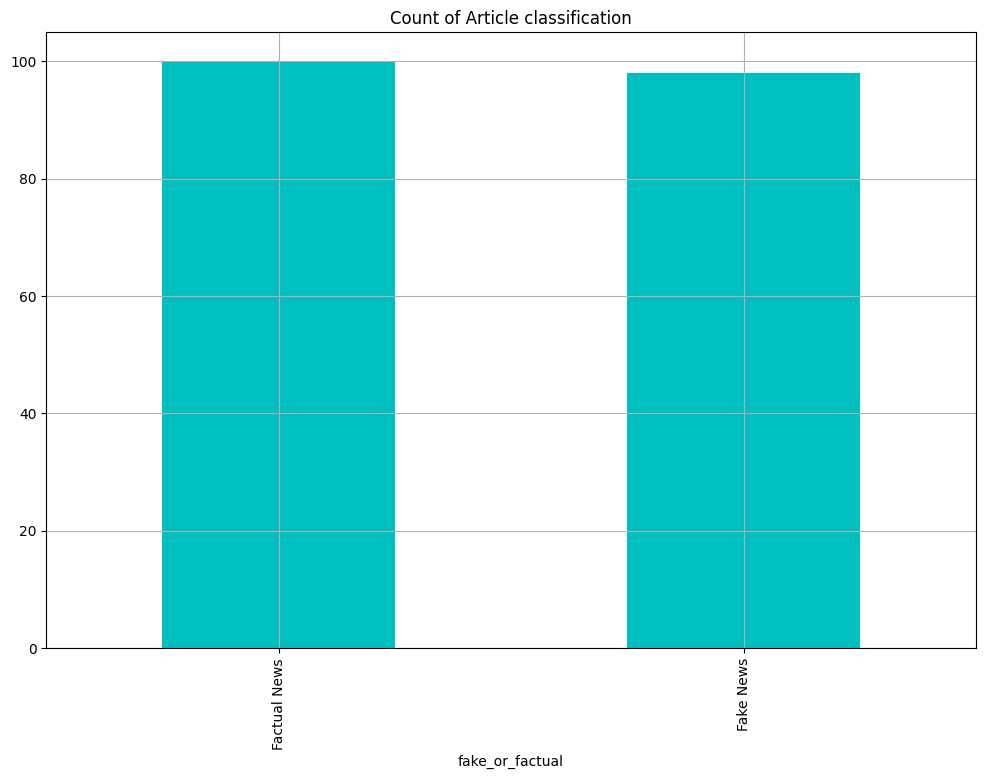

In [18]:
data['fake_or_factual'].value_counts().plot(kind='bar',color=default_plot_colour, grid=True)
plt.title("Count of Article classification")

In [26]:
data.shape

(198, 4)

In [27]:
data['content'] = data['title'] + " " + data['text']

In [29]:
def clean_text(text):

    # convert to lower case
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+", "", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # remove extra spaces
    text = text.strip()

    return text

In [30]:
data['content'] = data['content'].apply(clean_text)

In [31]:
data.head()

,title,text,date,fake_or_factual,content
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,hollyweird lib susan sarandon compares muslim ...
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,elijah cummings called trump out to his face a...
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,hillary clinton says half her cabinet will be ...
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,russian bombing of usbacked forces being discu...
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,britain says window to restore northern irelan...


In [34]:
X = data['content']
y = data['fake_or_factual']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
vectorizer = TfidfVectorizer(stop_words='english')

In [ ]:
X_train_tfidf = vectorizer.fit_transform(X_train)
# fit_transform = fit + transform
# fit = read training data , learn vocabulary, calculates word importance
# transform = Uses already learned vocabulary

In [ ]:
X_test_tfidf = vectorizer.transform(X_test) 

#Why We Use ONLY transform on Test Data 
# test data should remain unseen
# we must use SAME vocabulary learned from training

# Golden Rule
# Training = fit_transform()
# Testing / Prediction = transform()

In [39]:
model = LogisticRegression()

In [40]:
model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [41]:
y_pred = model.predict(X_test_tfidf)

In [42]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.85


In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

Factual News       0.81      0.89      0.85        19
   Fake News       0.89      0.81      0.85        21

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



In [ ]:
print(confusion_matrix(y_test, y_pred))
                #  Predicted
            #    FAKE    REAL
# 
# Actual FAKE      TP      FN
# Actual REAL      FP      TN
# TP = True positive

# Easy Memory Trick
# Think from prediction side.
# Positive = predicted FAKE
# Negative = predicted REAL


[[17  2]
 [ 4 17]]


In [53]:
news = """
Government announces free laptops for all citizens.
"""

# clean text
news = clean_text(news)

# convert to tfidf
news_vector = vectorizer.transform([news])

# predict
prediction = model.predict(news_vector)

print(prediction)

['Fake News']
